Found subjects: ['S03', 'S08', 'S10', 'S12', 'S13', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21']


KeyboardInterrupt: 

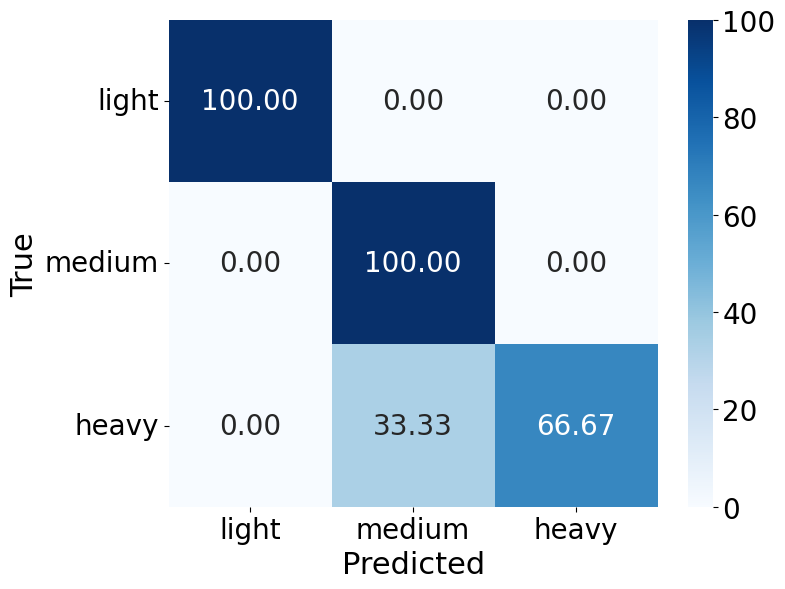

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support, accuracy_score
import seaborn as sns

# ===== CONFIG =====
DATA_DIR = "../data"
LABELS = ["light", "medium", "heavy"]
DPI = 300
FIGSIZE = (8, 6)

# ==================


def compute_confusion_and_metrics(y_true, y_pred):
    """Compute confusion matrix (counts) and metrics."""
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3])
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1, 2, 3], average="macro", zero_division=0
    )
    return cm, accuracy, precision, recall, f1

def save_confusion_matrix_image(cm, labels, title, save_path, figsize=FIGSIZE):
    """
    Salva l'immagine della matrice di confusione normalizzata per riga (in percentuale)
    utilizzando Seaborn per una migliore leggibilità.
    """
    # Map old args to new var names for clarity
    cm_abs = cm
    class_names = labels
    output_path = save_path
    
    # Inizio logica della nuova funzione
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calcola le percentuali normalizzate per riga (per 'True Label')
    cm_sum = cm_abs.sum(axis=1)[:, np.newaxis]
    
    # Evita divisione per zero se una classe non ha campioni reali
    cm_perc = np.nan_to_num(cm_abs.astype('float') / cm_sum)*100

    # Set di font (dalla tua nuova funzione, più leggibili)
    annot_font_size = 20
    label_font_size = 22
    tick_font_size = 20
    
    sns.heatmap(
        cm_perc, 
        annot=True, 
        cmap='Blues',
        fmt='.2f', 
        xticklabels=class_names, 
        yticklabels=class_names,
        ax=ax,
        annot_kws={"size": annot_font_size}, # Imposta font celle
        vmin=0, # Forza la scala di colori da 0.0
        vmax=100  # a 1.0 (100%)
    )
    
    # Titoli e label degli assi (con i font più grandi)
    ax.set_xlabel('Predicted', fontsize=label_font_size)
    ax.set_ylabel('True', fontsize=label_font_size)

    ax.tick_params(axis='x', labelsize=tick_font_size)
    ax.tick_params(axis='y', labelsize=tick_font_size, rotation=0)

    cbar_ax = fig.axes[-1]
    # Imposta la dimensione dei tick
    cbar_ax.tick_params(labelsize=tick_font_size)
    
    # Salvataggio (usando le costanti originali)
    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI)
    plt.close(fig)

def accuracy_score_from_cm(cm):
    """Compute accuracy, precision, recall, f1 from raw confusion matrix (counts)."""
    acc = np.trace(cm) / np.sum(cm) if np.sum(cm) > 0 else 0
    precision, recall, f1 = [], [], []
    for i in range(3):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_i = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        precision.append(prec)
        recall.append(rec)
        f1.append(f1_i)
    return acc, np.mean(precision), np.mean(recall), np.mean(f1)


def main():
    subjects = [d for d in os.listdir(DATA_DIR) if d.startswith("S")]
    print(f"Found subjects: {subjects}")

    for subj in subjects:
        subj_path = os.path.join(DATA_DIR, subj)
        acc_dir = os.path.join(subj_path, "accuracies")
        confusion_dir = os.path.join(acc_dir, "confusion_matrices")
        os.makedirs(acc_dir, exist_ok=True)
        os.makedirs(confusion_dir, exist_ok=True)

        # Aggregation containers
        agg_by_test = {}
        agg_by_box = {"trasp": [], "opaq": []}
        agg_total_myo = []
        agg_total_cv = []
        agg_total_combined = []

        metrics_rows = []

        # --- find test folders automatically
        tests = [d for d in os.listdir(subj_path) if d.startswith("test")]
        for test in tests:
            agg_by_test[test] = []

            for box in ["trasp", "opaq"]:
                csv_path = os.path.join(subj_path, test, box, "labels.csv")
                if not os.path.exists(csv_path):
                    continue

                df = pd.read_csv(csv_path)
                
                # ======== MODIFICA INIZIO ========
                # Carica le colonne come pandas Series
                y_true_series = df["label_real"]
                y_myo_series = df["label_myo"]
                y_cv_series = df["label_cv"]

                # Converti in numerico, i '-' diventeranno NaN (Not a Number)
                # 'coerce' forza gli errori di conversione (es. '-') a NaN
                y_true_numeric = pd.to_numeric(y_true_series, errors='coerce')
                y_myo_numeric = pd.to_numeric(y_myo_series, errors='coerce')
                y_cv_numeric = pd.to_numeric(y_cv_series, errors='coerce')

                # --- MYO ---
                # Filtra i NaN: calcola le metriche solo dove y_true E y_myo sono validi
                temp_df_myo = pd.DataFrame({'true': y_true_numeric, 'pred': y_myo_numeric}).dropna()
                
                y_true_myo_filt = temp_df_myo['true'].to_numpy()
                y_myo_filt = temp_df_myo['pred'].to_numpy()

                # Calcola solo se ci sono dati validi rimasti
                if len(y_true_myo_filt) > 0:
                    cm_myo, acc_myo, prec_myo, rec_myo, f1_myo = compute_confusion_and_metrics(y_true_myo_filt, y_myo_filt)
                else:
                    # Nessun dato valido (es. tutti '-'), registra zeri
                    cm_myo = np.zeros((3, 3))
                    acc_myo, prec_myo, rec_myo, f1_myo = 0.0, 0.0, 0.0, 0.0
                
                # Il resto del blocco Myo rimane invariato (usa i valori calcolati)
                np.savetxt(csv_path.replace("labels.csv", "cm_myo.csv"), cm_myo, fmt="%.4f", delimiter=",")
                save_confusion_matrix_image(
                    cm_myo, LABELS, f"{subj} - {test} {box} (Myo) [%]",
                    os.path.join(confusion_dir, f"{test}_{box}_myo.png")
                )
                metrics_rows.append(["Myo", test, box,
                                     round(acc_myo, 4), round(prec_myo, 4), round(rec_myo, 4), round(f1_myo, 4)])
                agg_by_test[test].append((cm_myo, "Myo"))
                agg_by_box[box].append((cm_myo, "Myo"))
                agg_total_myo.append(cm_myo)


                # --- CV ---
                # Filtra i NaN: calcola le metriche solo dove y_true E y_cv sono validi
                temp_df_cv = pd.DataFrame({'true': y_true_numeric, 'pred': y_cv_numeric}).dropna()
                
                y_true_cv_filt = temp_df_cv['true'].to_numpy()
                y_cv_filt = temp_df_cv['pred'].to_numpy()

                if len(y_true_cv_filt) > 0:
                    cm_cv, acc_cv, prec_cv, rec_cv, f1_cv = compute_confusion_and_metrics(y_true_cv_filt, y_cv_filt)
                else:
                    cm_cv = np.zeros((3, 3))
                    acc_cv, prec_cv, rec_cv, f1_cv = 0.0, 0.0, 0.0, 0.0
                
                # Il resto del blocco CV rimane invariato
                np.savetxt(csv_path.replace("labels.csv", "cm_cv.csv"), cm_cv, fmt="%.4f", delimiter=",")
                save_confusion_matrix_image(
                    cm_cv, LABELS, f"{subj} - {test} {box} (CV) [%]",
                    os.path.join(confusion_dir, f"{test}_{box}_cv.png")
                )
                metrics_rows.append(["CV", test, box,
                                     round(acc_cv, 4), round(prec_cv, 4), round(rec_cv, 4), round(f1_cv, 4)])
                agg_by_test[test].append((cm_cv, "CV"))
                agg_by_box[box].append((cm_cv, "CV"))
                agg_total_cv.append(cm_cv)


                # --- COMBINED (logica aggiornata per NaN) ---
                
                # Determina se Myo o CV sono corretti
                # (y_myo_numeric == y_true_numeric) darà False se y_myo_numeric è NaN
                myo_correct = (y_myo_numeric == y_true_numeric)
                cv_correct = (y_cv_numeric == y_true_numeric)
                
                # Logica 'Combined':
                # 1. Se Myo o CV sono corretti, usa y_true
                # 2. Altrimenti, usa la predizione di Myo
                # Usiamo .fillna(-1) per gestire il caso in cui Myo è NaN (non rilevato)
                # e anche CV è sbagliato. Questo -1 verrà filtrato.
                
                y_combined_series = pd.Series(np.where(
                    (myo_correct) | (cv_correct),  # se almeno una è corretta
                    y_true_numeric,                # conta come corretto (usa y_true)
                    y_myo_numeric.fillna(-1)       # se entrambe sbagliano (o sono NaN), prendi MYO (o -1 se Myo era NaN)
                ))

                # Filtra i NaN (da y_true) e i -1 (da Myo non rilevato)
                temp_df_comb = pd.DataFrame({'true': y_true_numeric, 'pred': y_combined_series}).dropna()
                temp_df_comb = temp_df_comb[temp_df_comb['pred'] != -1] # Rimuovi i casi non rilevati

                y_true_comb_filt = temp_df_comb['true'].to_numpy()
                y_comb_filt = temp_df_comb['pred'].to_numpy()

                if len(y_true_comb_filt) > 0:
                    cm_comb, acc_c, prec_c, rec_c, f1_c = compute_confusion_and_metrics(y_true_comb_filt, y_comb_filt)
                else:
                    cm_comb = np.zeros((3, 3))
                    acc_c, prec_c, rec_c, f1_c = 0.0, 0.0, 0.0, 0.0
                
                # ======== MODIFICA FINE ========
                
                # Il resto del blocco Combined rimane invariato
                np.savetxt(csv_path.replace("labels.csv", "cm_combined.csv"), cm_comb, fmt="%.4f", delimiter=",")
                save_confusion_matrix_image(
                    cm_comb, LABELS, f"{subj} - {test} {box} (Combined) [%]",
                    os.path.join(confusion_dir, f"{test}_{box}_combined.png")
                )
                metrics_rows.append(["Combined", test, box,
                                     round(acc_c, 4), round(prec_c, 4), round(rec_c, 4), round(f1_c, 4)])
                agg_by_test[test].append((cm_comb, "Combined"))
                agg_by_box[box].append((cm_comb, "Combined"))
                agg_total_combined.append(cm_comb)

        # ==== Aggregated Confusion Matrices ====
        def aggregate_and_save(group_dict, group_name):
            for key, cms in group_dict.items():
                if not cms:
                    continue
                for device in ["Myo", "CV", "Combined"]:
                    cm_sum = sum(cm for cm, d in cms if d == device)
                    if np.sum(cm_sum) == 0:
                        continue
                    np.savetxt(os.path.join(acc_dir, f"{key}_{device.lower()}_cm.csv"), cm_sum, fmt="%.4f", delimiter=",")
                    save_confusion_matrix_image(cm_sum, LABELS, f"{subj} - {key} ({device}) [%]",
                                                os.path.join(confusion_dir, f"{key}_{device.lower()}.png"))
                    acc, prec, rec, f1 = accuracy_score_from_cm(cm_sum)
                    metrics_rows.append([device, group_name, key,
                                         round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)])

        aggregate_and_save(agg_by_test, "test")
        aggregate_and_save(agg_by_box, "box")

        # --- totale soggetto ---
        for device, cm_list in [("Myo", agg_total_myo), ("CV", agg_total_cv), ("Combined", agg_total_combined)]:
            if cm_list:
                cm_sum = sum(cm_list)
                if np.sum(cm_sum) == 0: # Aggiunto controllo per somme vuote
                    continue
                np.savetxt(os.path.join(acc_dir, f"total_{device.lower()}_cm.csv"), cm_sum, fmt="%.4f", delimiter=",")
                save_confusion_matrix_image(cm_sum, LABELS, f"{subj} - Total ({device}) [%]",
                                            os.path.join(confusion_dir, f"total_{device.lower()}.png"))
                acc, prec, rec, f1 = accuracy_score_from_cm(cm_sum)
                metrics_rows.append([device, "total", "total",
                                     round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)])

        # --- salva riepilogo metriche
        metrics_df = pd.DataFrame(
            metrics_rows,
            columns=["device", "test", "box", "accuracy", "precision", "recall", "f1"]
        )
        metrics_df.to_csv(os.path.join(acc_dir, "summary_metrics.csv"), index=False, float_format="%.4f")
        print(f"✅ Finished {subj}")


if __name__ == "__main__":
    main()

In [19]:
def main_global():
    
    # --- Setup Global Directories ---
    global_dir = os.path.join(DATA_DIR, "all")
    global_acc_dir = os.path.join(global_dir, "accuracies")
    global_confusion_dir = os.path.join(global_acc_dir, "confusion_matrices")
    global_metrics_by_condition_dir = os.path.join(global_acc_dir, "metrics_by_condition")
    
    os.makedirs(global_acc_dir, exist_ok=True)
    os.makedirs(global_confusion_dir, exist_ok=True)
    os.makedirs(global_metrics_by_condition_dir, exist_ok=True)

    subjects = [d for d in os.listdir(DATA_DIR) if d.startswith("S")]
    print(f"Found subjects: {subjects}")

    all_metrics_dfs = []
    
    # Global Aggregation containers (for raw CMs)
    global_agg_by_test = {}
    global_agg_by_box = {"trasp": [], "opaq": []}
    global_agg_by_test_and_box = {} # <--- MODIFICA: Nuovo contenitore per (test, box)
    global_agg_total_myo = []
    global_agg_total_cv = []
    global_agg_total_combined = []

    # --- 1. Load all summary_metrics.csv and all raw CMs ---
    for subj in subjects:
        subj_path = os.path.join(DATA_DIR, subj)
        
        # Load summary_metrics.csv
        metrics_csv_path = os.path.join(subj_path, "accuracies", "summary_metrics.csv")
        if os.path.exists(metrics_csv_path):
            try:
                df = pd.read_csv(metrics_csv_path)
                df["subject"] = subj
                all_metrics_dfs.append(df)
            except pd.errors.EmptyDataError:
                print(f"Skipping empty metrics file for {subj}")
        else:
            print(f"Missing summary_metrics.csv for {subj}")

        # Load raw CMs for global aggregation
        tests = [d for d in os.listdir(subj_path) if d.startswith("test")]
        for test in tests:
            if test not in global_agg_by_test:
                global_agg_by_test[test] = []
                
            for box in ["trasp", "opaq"]:
                # <--- MODIFICA: Definisci la chiave combinata
                combo_key = f"{test}_{box}" 
                if combo_key not in global_agg_by_test_and_box:
                    global_agg_by_test_and_box[combo_key] = []

                base_path = os.path.join(subj_path, test, box)
                for device, cm_file in [
                    ("Myo", "cm_myo.csv"),
                    ("CV", "cm_cv.csv"),
                    ("Combined", "cm_combined.csv"),
                ]:
                    cm_path = os.path.join(base_path, cm_file)
                    if os.path.exists(cm_path):
                        try:
                            cm = np.loadtxt(cm_path, delimiter=",")
                            
                            # Popola tutti i contenitori
                            global_agg_by_test[test].append((cm, device))
                            global_agg_by_box[box].append((cm, device))
                            global_agg_by_test_and_box[combo_key].append((cm, device)) # <--- MODIFICA

                            if device == "Myo":
                                global_agg_total_myo.append(cm)
                            elif device == "CV":
                                global_agg_total_cv.append(cm)
                            elif device == "Combined":
                                global_agg_total_combined.append(cm)
                        except Exception as e:
                            print(f"Error loading {cm_path}: {e}")

    if not all_metrics_dfs:
        print("No metrics files found. Exiting.")
        return

    # --- 2. Concatenate all metrics for analysis ---
    all_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

    # --- 3. MYO vs CV Wins Analysis ---
    # (Questa sezione rimane invariata, analizza i file individuali)
    print("Calculating Myo vs CV wins...")
    try:
        pivot_df = all_metrics_df.pivot_table(
            index=["subject", "test", "box"],
            columns="device",
            values="accuracy"
        ).reset_index()
    
        pivot_df['winner'] = np.where(
            pivot_df.get('Myo', 0) > pivot_df.get('CV', 0),
            'MYO',
            np.where(
                pivot_df.get('CV', 0) > pivot_df.get('Myo', 0),
                'CV',
                'Tie' 
            )
        )
    
        wins_summary = (
            pivot_df.groupby(['test', 'box'])['winner']
            .value_counts()
            .unstack(fill_value=0)
        )
    
        wins_summary_path = os.path.join(global_acc_dir, "myo_vs_cv_wins.csv")
        wins_summary.to_csv(wins_summary_path)
    
        print(f"Saved MYO vs CV wins summary to {wins_summary_path}")
    
    except Exception as e:
        print(f"Could not generate MYO vs CV wins summary. Error: {e}")
        print("Pivot head:\n", all_metrics_df.head())

    # --- 4. Save separate CSVs for each condition ---
    # (Questa sezione rimane invariata, salva i dati per soggetto)
    print("Saving metrics by condition...")
    grouped = all_metrics_df.groupby(["test", "box"])
    for name, group_df in grouped:
        test_name, box_name = name
        filename = f"{test_name}_{box_name}.csv"
        save_path = os.path.join(global_metrics_by_condition_dir, filename)
        
        try:
            pivoted_group = group_df.pivot_table(
                index="subject", 
                columns=["device"], 
                values=["accuracy", "precision", "recall", "f1"]
            )
            pivoted_group = pivoted_group.swaplevel(0, 1, axis=1).sort_index(axis=1)
            pivoted_group.to_csv(save_path, float_format="%.4f")
        except:
            group_df.to_csv(save_path, index=False, float_format="%.4f")

    print(f"Saved metrics by condition to {global_metrics_by_condition_dir}")

    # --- 5. Calculate and Save Global Aggregated Metrics ---
    print("Calculating global metrics...")
    global_metrics_rows = []

    def aggregate_and_save_global(group_dict, group_name):
        for key, cms in group_dict.items():
            if not cms:
                print(f"No CMs found for group {group_name} - key {key}")
                continue
            for device in ["Myo", "CV", "Combined"]:
                cm_list_for_device = [cm for cm, d in cms if d == device]
                if not cm_list_for_device:
                    continue
                    
                cm_sum = sum(cm_list_for_device)
                if np.sum(cm_sum) == 0: # <--- MODIFICA: Aggiunto controllo per somma 0
                    continue

                cm_csv_path = os.path.join(global_acc_dir, f"{key}_{device.lower()}_cm.csv")
                np.savetxt(cm_csv_path, cm_sum, fmt="%.4f", delimiter=",")
                
                img_title = f"Global - {key} ({device}) [%]"
                img_path = os.path.join(global_confusion_dir, f"{key}_{device.lower()}.png")
                save_confusion_matrix_image(cm_sum, LABELS, img_title, img_path)
                
                acc, prec, rec, f1 = accuracy_score_from_cm(cm_sum)
                global_metrics_rows.append([device, group_name, key,
                                            round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)])

    # Aggregati per TEST (es. test1, test2)
    aggregate_and_save_global(global_agg_by_test, "test")
    
    # Aggregati per BOX (es. trasp, opaq)
    aggregate_and_save_global(global_agg_by_box, "box")

    # <--- MODIFICA: Nuova aggregazione per TEST+BOX (es. test1_trasp, test1_opaq)
    print("Calculating global metrics for (test, box) combinations...")
    aggregate_and_save_global(global_agg_by_test_and_box, "test_box")

    # Aggregati TOTALI
    for device, cm_list in [
        ("Myo", global_agg_total_myo),
        ("CV", global_agg_total_cv),
        ("Combined", global_agg_total_combined),
    ]:
        if cm_list:
            cm_sum = sum(cm_list)
            if np.sum(cm_sum) == 0: # <--- MODIFICA: Aggiunto controllo per somma 0
                continue
                
            cm_csv_path = os.path.join(global_acc_dir, f"total_{device.lower()}_cm.csv")
            np.savetxt(cm_csv_path, cm_sum, fmt="%.4f", delimiter=",")
            
            img_title = f"Global - Total ({device}) [%]"
            img_path = os.path.join(global_confusion_dir, f"total_{device.lower()}.png")
            save_confusion_matrix_image(cm_sum, LABELS, img_title, img_path)
            
            acc, prec, rec, f1 = accuracy_score_from_cm(cm_sum)
            global_metrics_rows.append([device, "total", "total",
                                        round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)])

    # --- Save global metrics summary ---
    global_metrics_df = pd.DataFrame(
        global_metrics_rows,
        columns=["device", "test", "box", "accuracy", "precision", "recall", "f1"]
    )
    global_summary_path = os.path.join(global_acc_dir, "summary_metrics.csv")
    global_metrics_df.to_csv(global_summary_path, index=False, float_format="%.4f")
    print(f"✅ Finished global analysis. Results in {global_acc_dir}")


if __name__ == "__main__":
    # Assicurati di chiamare main_global() se è questa la funzione che vuoi eseguire
    # main() # Esegue l'analisi per soggetto
    main_global() # Esegue l'analisi globale

Found subjects: ['S03', 'S08', 'S10', 'S12', 'S13', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21']
Calculating Myo vs CV wins...
Saved MYO vs CV wins summary to ../data\all\accuracies\myo_vs_cv_wins.csv
Saving metrics by condition...
Saved metrics by condition to ../data\all\accuracies\metrics_by_condition
Calculating global metrics...
Calculating global metrics for (test, box) combinations...
✅ Finished global analysis. Results in ../data\all\accuracies
